In [2]:
# 1. Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

In [3]:
# 2. Load Dataset

data_path = Path("../data/raw")

dongsi = pd.read_csv(data_path / "PRSA_Data_Dongsi_20130301-20170228.csv")
tiantan = pd.read_csv(data_path / "PRSA_Data_Tiantan_20130301-20170228.csv")
huairou = pd.read_csv(data_path / "PRSA_Data_Huairou_20130301-20170228.csv")
dingling = pd.read_csv(data_path / "PRSA_Data_Dingling_20130301-20170228.csv")

In [4]:
# 3. Select Required 4 Stations

selected_stations = [dongsi, tiantan, huairou, dingling]

for data in selected_stations:
    print(data["station"].iloc[0], data.shape)

Dongsi (35064, 18)
Tiantan (35064, 18)
Huairou (35064, 18)
Dingling (35064, 18)


In [5]:
# Combine selected 4 stations into one dataset

df = pd.concat(selected_stations, ignore_index=True)

print("Combined dataset shape:", df.shape)
df.head()

Combined dataset shape: (140256, 18)


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,9.0,9.0,3.0,17.0,300.0,89.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Dongsi
1,2,2013,3,1,1,4.0,4.0,3.0,16.0,300.0,88.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Dongsi
2,3,2013,3,1,2,7.0,7.0,NaN,17.0,300.0,60.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Dongsi
3,4,2013,3,1,3,3.0,3.0,5.0,18.0,NaN,NaN,-1.4,1026.2,-25.5,0.0,N,4.9,Dongsi
4,5,2013,3,1,4,3.0,3.0,7.0,NaN,200.0,84.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Dongsi


In [6]:
# 4. Merge Dataset

df["datetime"] = pd.to_datetime(df[["year", "month", "day", "hour"]])

df = df.sort_values(by=["station", "datetime"]).reset_index(drop=True)

print("Merged dataset shape:", df.shape)
print("Date range:", df["datetime"].min(), "to", df["datetime"].max())
print("Stations:", df["station"].unique())
df.head()

Merged dataset shape: (140256, 19)
Date range: 2013-03-01 00:00:00 to 2017-02-28 23:00:00
Stations: ['Dingling' 'Dongsi' 'Huairou' 'Tiantan']


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
0,1,2013,3,1,0,4.0,4.0,3.0,NaN,200.0,82.0,-2.3,1020.8,-19.7,0.0,E,0.5,Dingling,2013-03-01 00:00:00
1,2,2013,3,1,1,7.0,7.0,3.0,NaN,200.0,80.0,-2.5,1021.3,-19.0,0.0,ENE,0.7,Dingling,2013-03-01 01:00:00
2,3,2013,3,1,2,5.0,5.0,3.0,2.0,200.0,79.0,-3.0,1021.3,-19.9,0.0,ENE,0.2,Dingling,2013-03-01 02:00:00
3,4,2013,3,1,3,6.0,6.0,3.0,NaN,200.0,79.0,-3.6,1021.8,-19.1,0.0,NNE,1.0,Dingling,2013-03-01 03:00:00
4,5,2013,3,1,4,5.0,5.0,3.0,NaN,200.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1,Dingling,2013-03-01 04:00:00


In [7]:
# 5. Data Understanding

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140256 entries, 0 to 140255
Data columns (total 19 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   No        140256 non-null  int64         
 1   year      140256 non-null  int64         
 2   month     140256 non-null  int64         
 3   day       140256 non-null  int64         
 4   hour      140256 non-null  int64         
 5   PM2.5     137097 non-null  float64       
 6   PM10      137673 non-null  float64       
 7   SO2       136765 non-null  float64       
 8   NO2       135038 non-null  float64       
 9   CO        132499 non-null  float64       
 10  O3        136384 non-null  float64       
 11  TEMP      140112 non-null  float64       
 12  PRES      140113 non-null  float64       
 13  DEWP      140110 non-null  float64       
 14  RAIN      140110 non-null  float64       
 15  wd        139658 non-null  object        
 16  WSPM      140136 non-null  float64    

In [8]:
# Dataset shape

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 140256
Number of columns: 19


In [9]:
# Column names

df.columns

Index(['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2',
       'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station',
       'datetime'],
      dtype='object')

In [10]:
# Data types

df.dtypes

No                   int64
year                 int64
month                int64
day                  int64
hour                 int64
PM2.5              float64
PM10               float64
SO2                float64
NO2                float64
CO                 float64
O3                 float64
TEMP               float64
PRES               float64
DEWP               float64
RAIN               float64
wd                  object
WSPM               float64
station             object
datetime    datetime64[ns]
dtype: object

In [11]:
# Missing values

missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_values

,Missing Values,Missing Percentage
No,0,0.000000
year,0,0.000000
month,0,0.000000
day,0,0.000000
hour,0,0.000000
PM2.5,3159,2.252310
PM10,2583,1.841632
SO2,3491,2.489020
NO2,5218,3.720340
CO,7757,5.530601


In [12]:
# Duplicate rows

print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [13]:
# Statistical summary

df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,datetime
count,140256.000,140256.000000,140256.000000,140256.000000,140256.000000,137097.000000,137673.000000,136765.000000,135038.000000,132499.000000,136384.000000,140112.000000,140113.000000,140110.000000,140110.000000,140136.000000,140256
mean,17532.500,2014.662560,6.522930,15.729637,11.500000,76.008598,97.999255,14.197895,41.772859,1137.793764,60.366923,13.368759,1010.114517,2.159931,0.064086,1.806885,2015-03-01 11:29:59.999999744
min,1.000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.400000,-43.400000,0.000000,0.000000,2013-03-01 00:00:00
25%,8766.750,2014.000000,4.000000,8.000000,5.750000,18.000000,32.000000,2.000000,17.000000,400.000000,16.000000,3.000000,1001.700000,-9.400000,0.000000,1.000000,2014-03-01 05:45:00
50%,17532.500,2015.000000,7.000000,16.000000,11.500000,51.000000,75.000000,6.000000,34.000000,800.000000,50.000000,14.400000,1009.800000,2.600000,0.000000,1.400000,2015-03-01 11:30:00
75%,26298.250,2016.000000,10.000000,23.000000,17.250000,106.000000,136.000000,17.000000,60.000000,1400.000000,84.000000,23.100000,1018.300000,14.900000,0.000000,2.300000,2016-02-29 17:15:00
max,35064.000,2017.000000,12.000000,31.000000,23.000000,881.000000,993.000000,315.000000,258.000000,10000.000000,1071.000000,41.400000,1042.000000,29.100000,52.100000,12.900000,2017-02-28 23:00:00
std,10122.141,1.177201,3.448715,8.800123,6.922211,78.468402,88.648097,19.734570,32.142645,1064.570208,56.640642,11.521420,10.482069,13.879616,0.794380,1.271235,NaN


In [14]:
# Station-wise row count

df["station"].value_counts()

station
Dingling    35064
Dongsi      35064
Huairou     35064
Tiantan     35064
Name: count, dtype: int64

In [15]:
# 6. Data Preprocessing

df_clean = df.copy()

In [16]:
# Remove duplicate rows

df_clean = df_clean.drop_duplicates()

print("Shape after removing duplicates:", df_clean.shape)

Shape after removing duplicates: (140256, 19)


In [17]:
# Handle missing numerical values using station-wise interpolation and median filling

numeric_cols = [
    "PM2.5", "PM10", "SO2", "NO2", "CO", "O3",
    "TEMP", "PRES", "DEWP", "RAIN", "WSPM"
]

for col in numeric_cols:
    df_clean[col] = df_clean.groupby("station")[col].transform(
        lambda x: x.interpolate(method="linear")
    )
    df_clean[col] = df_clean.groupby("station")[col].transform(
        lambda x: x.fillna(x.median())
    )

In [18]:
# Handle missing wind direction values using station-wise mode

df_clean["wd"] = df_clean.groupby("station")["wd"].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "Unknown")
)

In [19]:
# Check missing values after cleaning

df_clean.isnull().sum()

No          0
year        0
month       0
day         0
hour        0
PM2.5       0
PM10        0
SO2         0
NO2         0
CO          0
O3          0
TEMP        0
PRES        0
DEWP        0
RAIN        0
wd          0
WSPM        0
station     0
datetime    0
dtype: int64

In [20]:
# Feature engineering: create time-based variables

df_clean["year"] = df_clean["datetime"].dt.year
df_clean["month"] = df_clean["datetime"].dt.month
df_clean["day"] = df_clean["datetime"].dt.day
df_clean["hour"] = df_clean["datetime"].dt.hour
df_clean["day_of_week"] = df_clean["datetime"].dt.dayofweek

In [21]:
# Feature engineering: create season column

def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df_clean["season"] = df_clean["month"].apply(get_season)

In [22]:
# Feature engineering: create PM2.5 pollution category

def pm25_category(value):
    if value <= 35:
        return "Good"
    elif value <= 75:
        return "Moderate"
    elif value <= 115:
        return "Unhealthy"
    elif value <= 150:
        return "Very Unhealthy"
    else:
        return "Hazardous"

df_clean["PM25_Category"] = df_clean["PM2.5"].apply(pm25_category)

In [23]:
# Final cleaned dataset check

print("Final cleaned dataset shape:", df_clean.shape)
df_clean.head()

Final cleaned dataset shape: (140256, 22)


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,...,PRES,DEWP,RAIN,wd,WSPM,station,datetime,day_of_week,season,PM25_Category
0,1,2013,3,1,0,4.0,4.0,3.0,19.000000,200.0,...,1020.8,-19.7,0.0,E,0.5,Dingling,2013-03-01 00:00:00,4,Spring,Good
1,2,2013,3,1,1,7.0,7.0,3.0,19.000000,200.0,...,1021.3,-19.0,0.0,ENE,0.7,Dingling,2013-03-01 01:00:00,4,Spring,Good
2,3,2013,3,1,2,5.0,5.0,3.0,2.000000,200.0,...,1021.3,-19.9,0.0,ENE,0.2,Dingling,2013-03-01 02:00:00,4,Spring,Good
3,4,2013,3,1,3,6.0,6.0,3.0,2.666667,200.0,...,1021.8,-19.1,0.0,NNE,1.0,Dingling,2013-03-01 03:00:00,4,Spring,Good
4,5,2013,3,1,4,5.0,5.0,3.0,3.333333,200.0,...,1022.3,-19.4,0.0,N,2.1,Dingling,2013-03-01 04:00:00,4,Spring,Good


In [24]:
# Save cleaned dataset

df_clean.to_csv("../data/processed/cleaned_air_quality.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [25]:
# 7. EDA Visualisations

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12

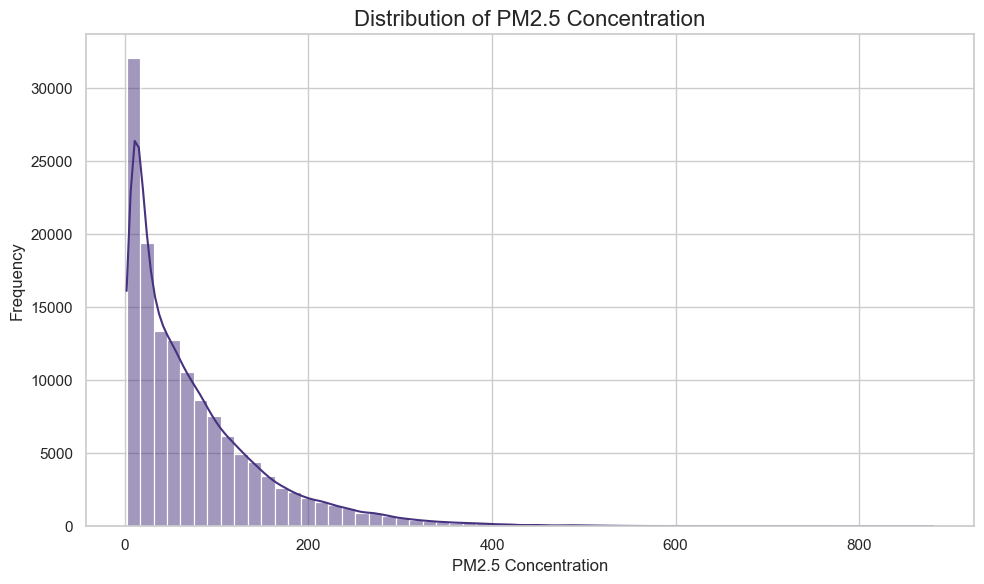

In [26]:
# PM2.5 Distribution

plt.figure(figsize=(10, 6))
sns.histplot(df_clean["PM2.5"], bins=60, kde=True)
plt.title("Distribution of PM2.5 Concentration")
plt.xlabel("PM2.5 Concentration")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

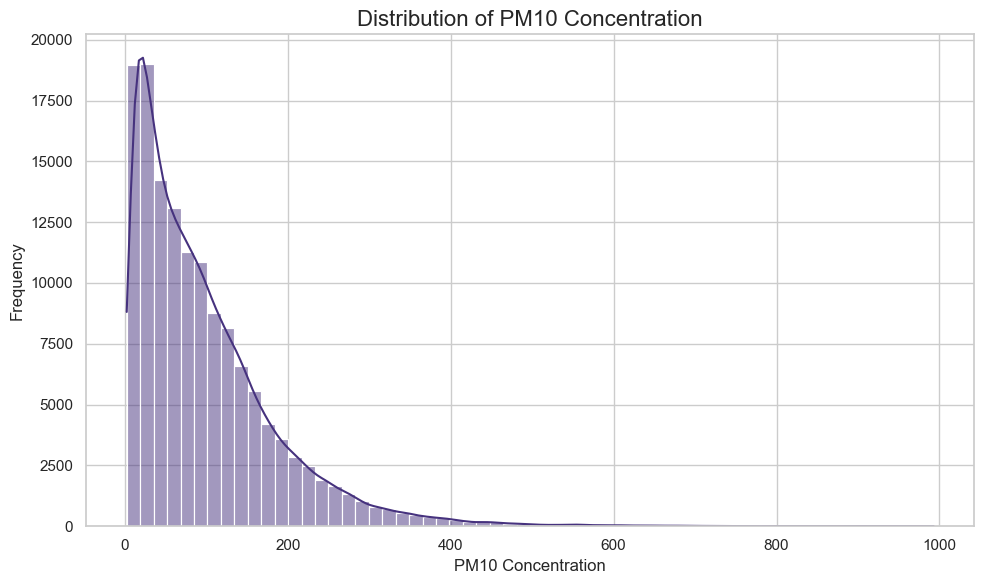

In [27]:
# PM10 Distribution

plt.figure(figsize=(10, 6))
sns.histplot(df_clean["PM10"], bins=60, kde=True)
plt.title("Distribution of PM10 Concentration")
plt.xlabel("PM10 Concentration")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

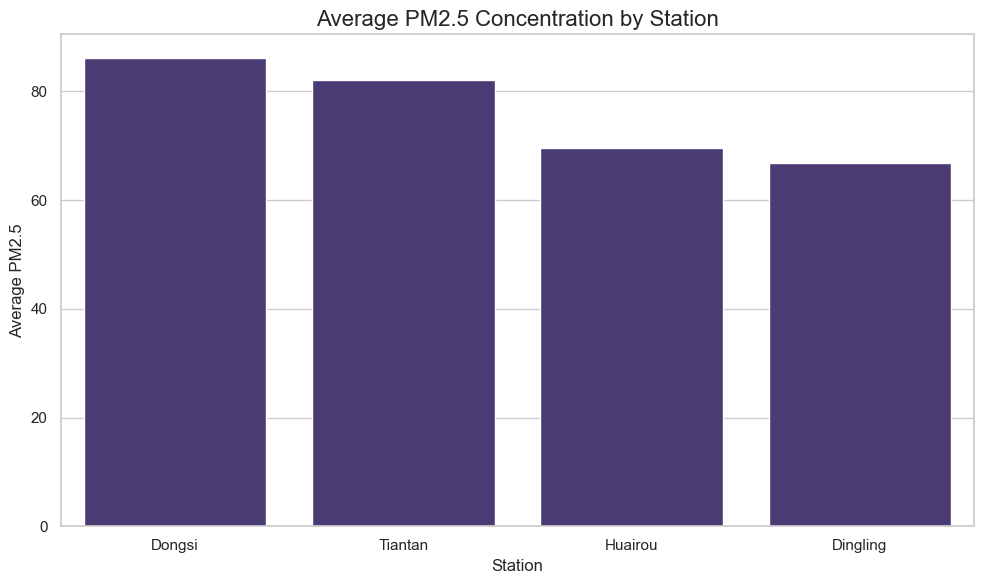

In [28]:
# Average PM2.5 by Station

station_pm25 = df_clean.groupby("station")["PM2.5"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=station_pm25.index, y=station_pm25.values)
plt.title("Average PM2.5 Concentration by Station")
plt.xlabel("Station")
plt.ylabel("Average PM2.5")
plt.tight_layout()
plt.show()

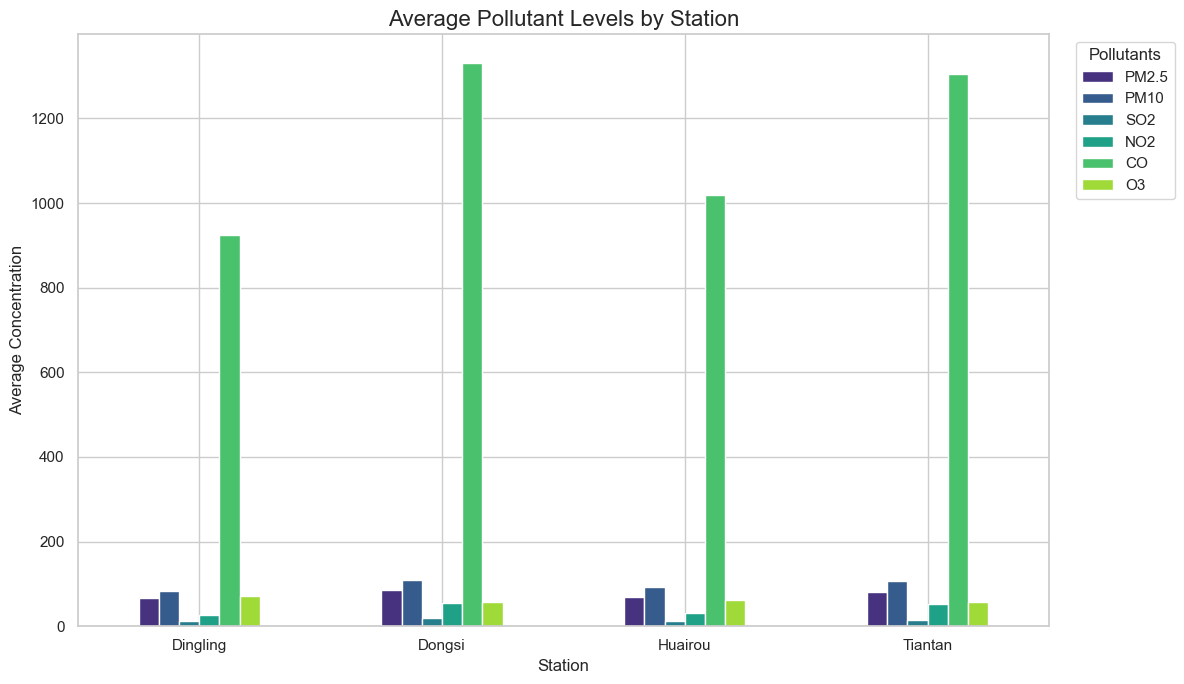

In [29]:
# Average Pollutants by Station

pollutants = ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3"]

station_pollution = df_clean.groupby("station")[pollutants].mean()

station_pollution.plot(kind="bar", figsize=(12, 7))
plt.title("Average Pollutant Levels by Station")
plt.xlabel("Station")
plt.ylabel("Average Concentration")
plt.xticks(rotation=0)
plt.legend(title="Pollutants", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

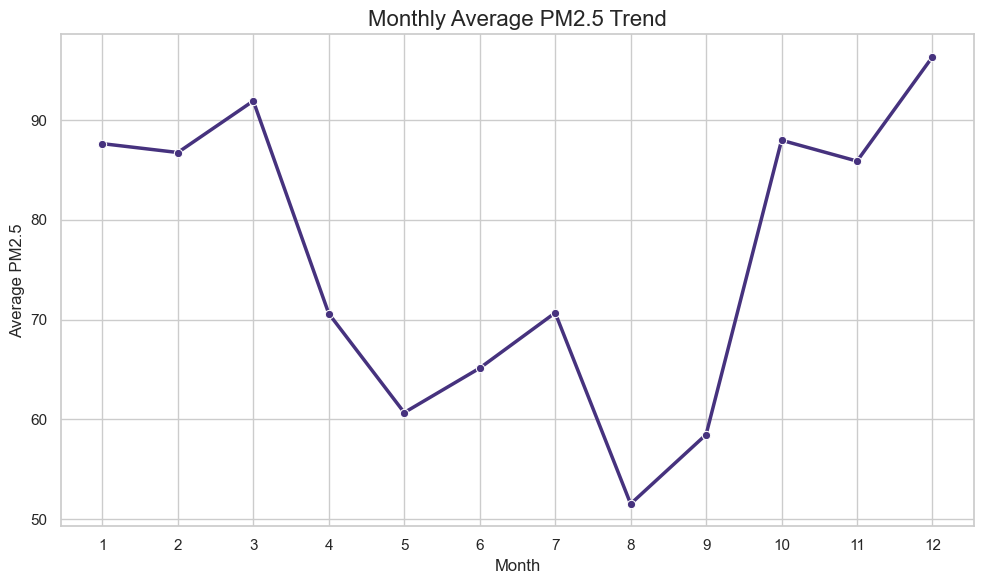

In [30]:
# Monthly Average PM2.5 Trend

monthly_pm25 = df_clean.groupby("month")["PM2.5"].mean()

plt.figure(figsize=(10, 6))
sns.lineplot(x=monthly_pm25.index, y=monthly_pm25.values, marker="o", linewidth=2.5)
plt.title("Monthly Average PM2.5 Trend")
plt.xlabel("Month")
plt.ylabel("Average PM2.5")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

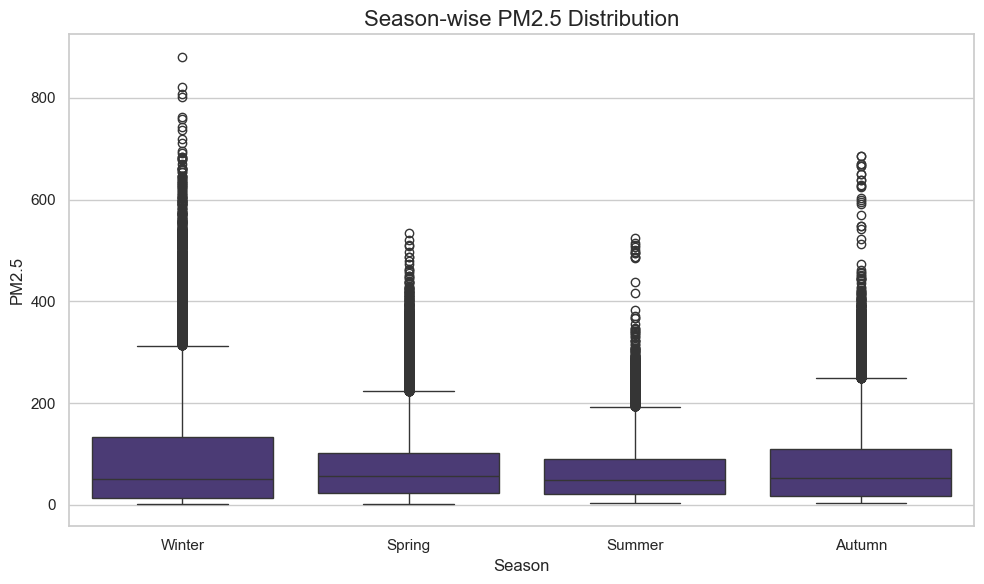

In [31]:
# Season-wise PM2.5 Comparison

season_order = ["Winter", "Spring", "Summer", "Autumn"]

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x="season", y="PM2.5", order=season_order)
plt.title("Season-wise PM2.5 Distribution")
plt.xlabel("Season")
plt.ylabel("PM2.5")
plt.tight_layout()
plt.show()

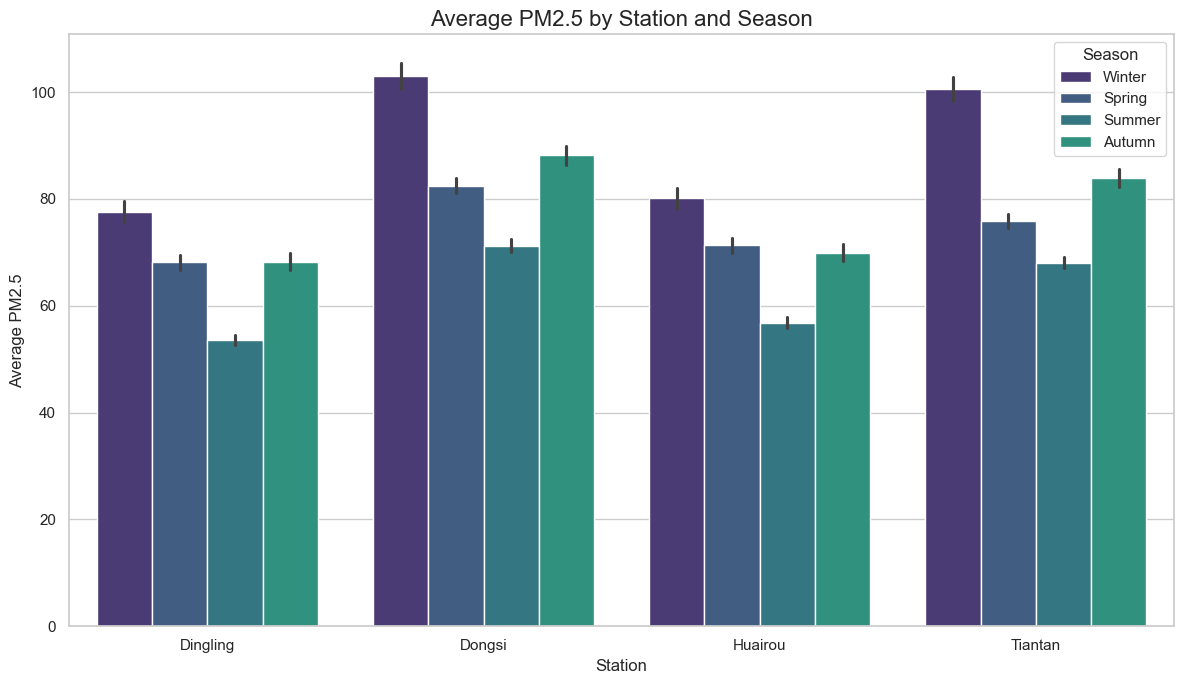

In [32]:
# PM2.5 by Station and Season

plt.figure(figsize=(12, 7))
sns.barplot(data=df_clean, x="station", y="PM2.5", hue="season", hue_order=season_order)
plt.title("Average PM2.5 by Station and Season")
plt.xlabel("Station")
plt.ylabel("Average PM2.5")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

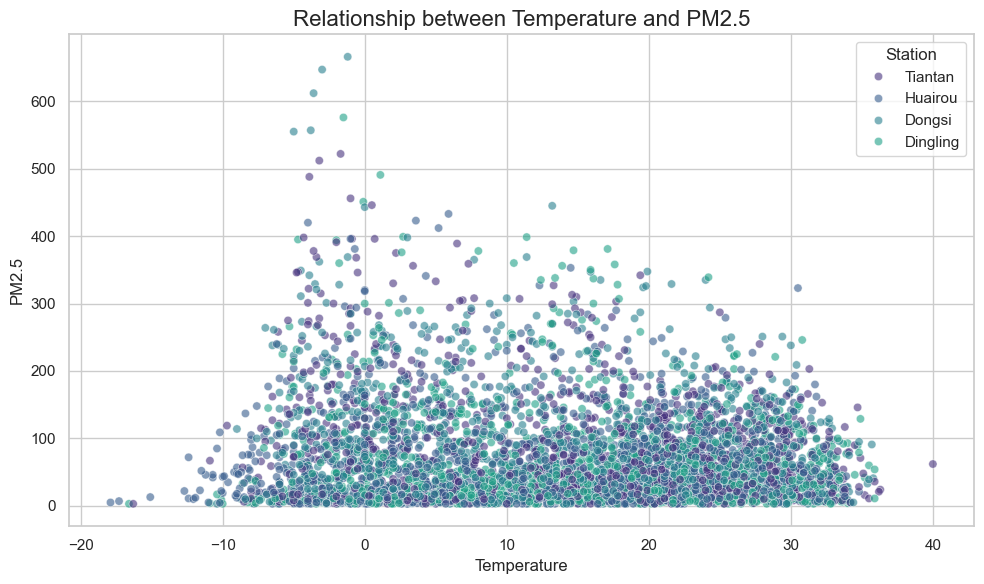

In [33]:
# PM2.5 vs Temperature

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean.sample(5000, random_state=42), x="TEMP", y="PM2.5", hue="station", alpha=0.6)
plt.title("Relationship between Temperature and PM2.5")
plt.xlabel("Temperature")
plt.ylabel("PM2.5")
plt.legend(title="Station")
plt.tight_layout()
plt.show()

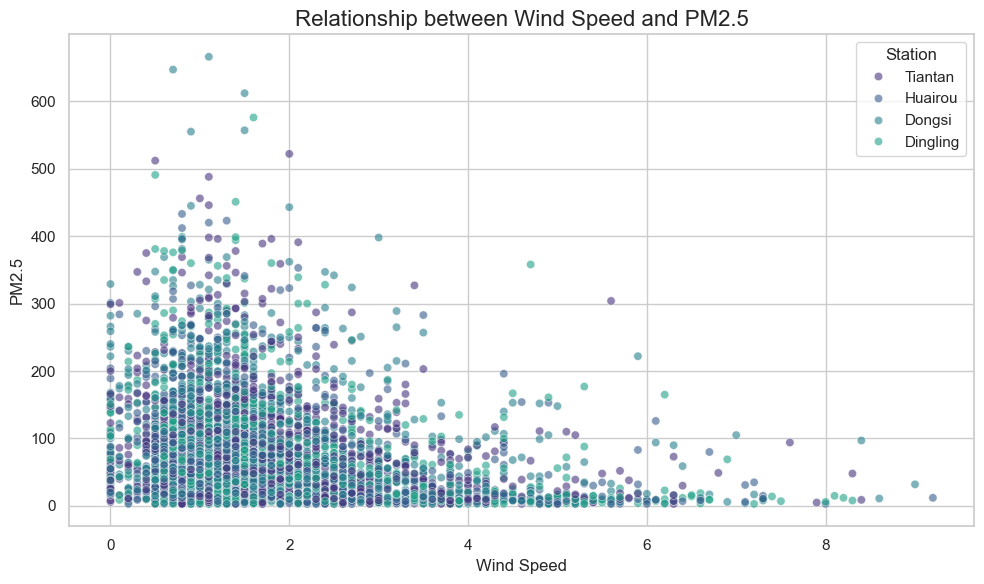

In [34]:
# PM2.5 vs Wind Speed

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean.sample(5000, random_state=42), x="WSPM", y="PM2.5", hue="station", alpha=0.6)
plt.title("Relationship between Wind Speed and PM2.5")
plt.xlabel("Wind Speed")
plt.ylabel("PM2.5")
plt.legend(title="Station")
plt.tight_layout()
plt.show()

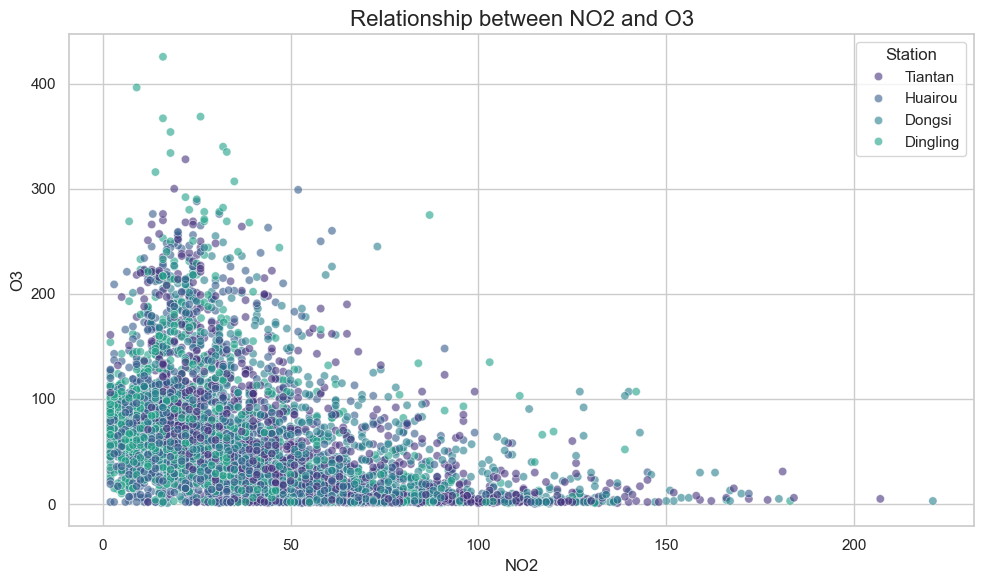

In [35]:
# NO2 vs O3

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean.sample(5000, random_state=42), x="NO2", y="O3", hue="station", alpha=0.6)
plt.title("Relationship between NO2 and O3")
plt.xlabel("NO2")
plt.ylabel("O3")
plt.legend(title="Station")
plt.tight_layout()
plt.show()

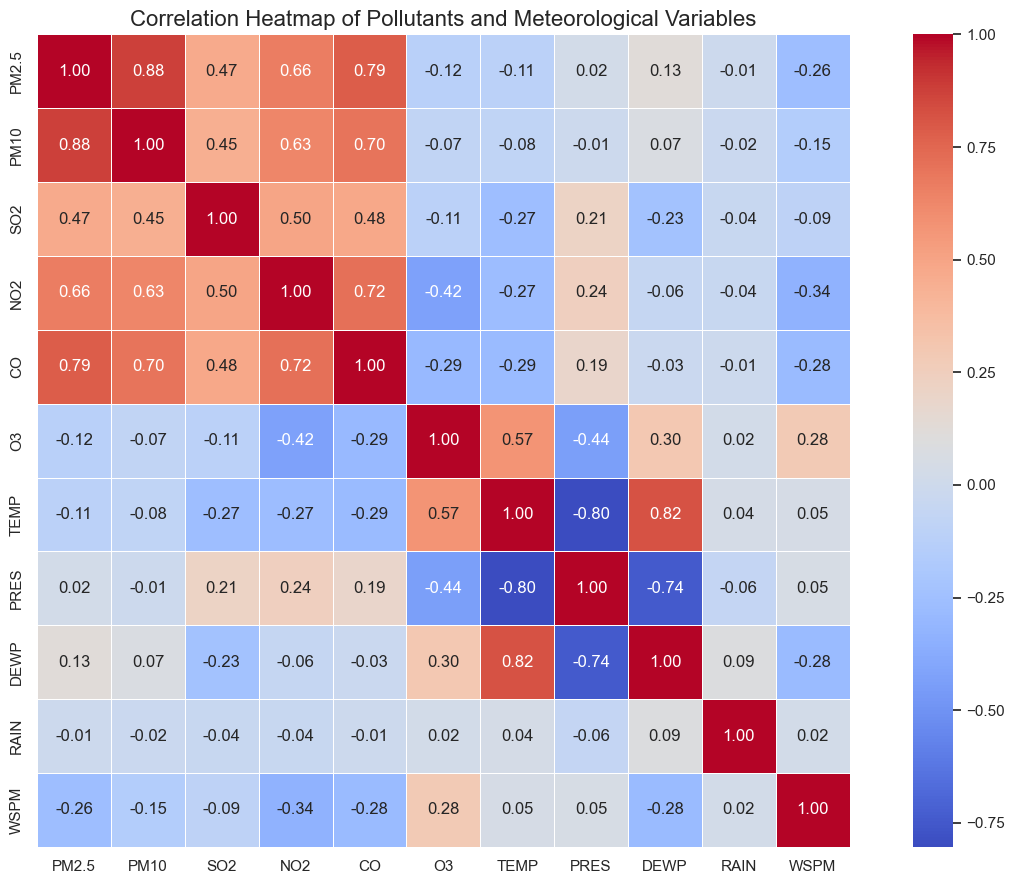

In [36]:
# Correlation Heatmap

numeric_columns = [
    "PM2.5", "PM10", "SO2", "NO2", "CO", "O3",
    "TEMP", "PRES", "DEWP", "RAIN", "WSPM"
]

plt.figure(figsize=(13, 9))
correlation_matrix = df_clean[numeric_columns].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cmap="coolwarm",
    square=True
)

plt.title("Correlation Heatmap of Pollutants and Meteorological Variables")
plt.tight_layout()
plt.show()

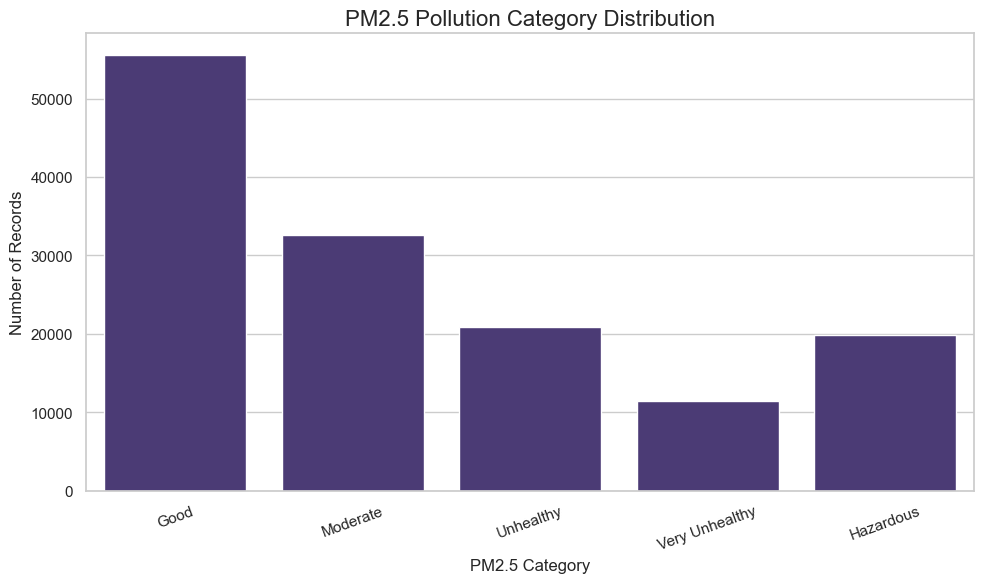

In [37]:
# PM2.5 Pollution Category Count

category_order = ["Good", "Moderate", "Unhealthy", "Very Unhealthy", "Hazardous"]

plt.figure(figsize=(10, 6))
sns.countplot(data=df_clean, x="PM25_Category", order=category_order)
plt.title("PM2.5 Pollution Category Distribution")
plt.xlabel("PM2.5 Category")
plt.ylabel("Number of Records")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

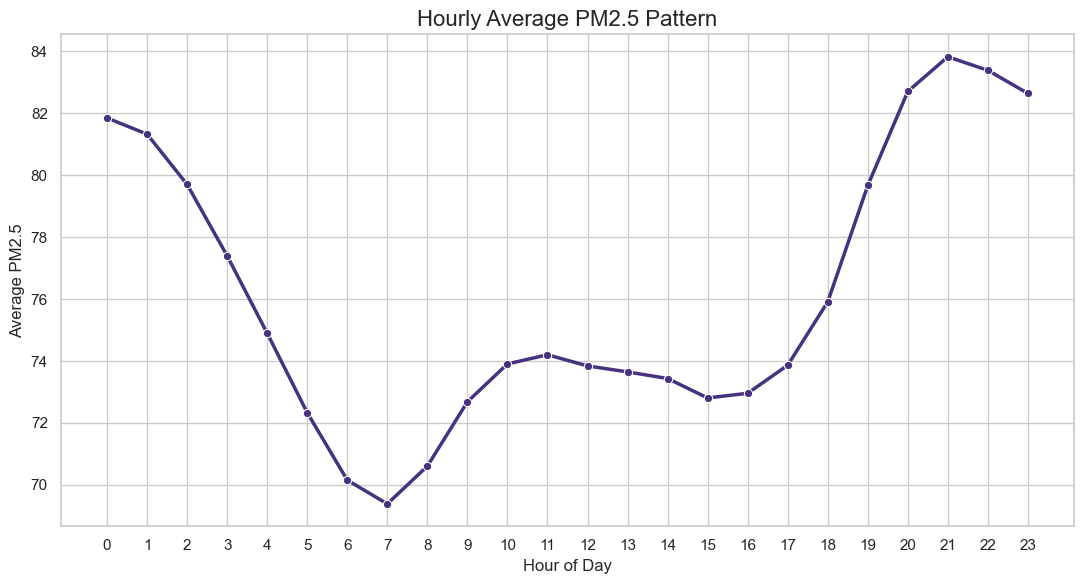

In [38]:
# Hourly PM2.5 Pattern

hourly_pm25 = df_clean.groupby("hour")["PM2.5"].mean()

plt.figure(figsize=(11, 6))
sns.lineplot(x=hourly_pm25.index, y=hourly_pm25.values, marker="o", linewidth=2.5)
plt.title("Hourly Average PM2.5 Pattern")
plt.xlabel("Hour of Day")
plt.ylabel("Average PM2.5")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

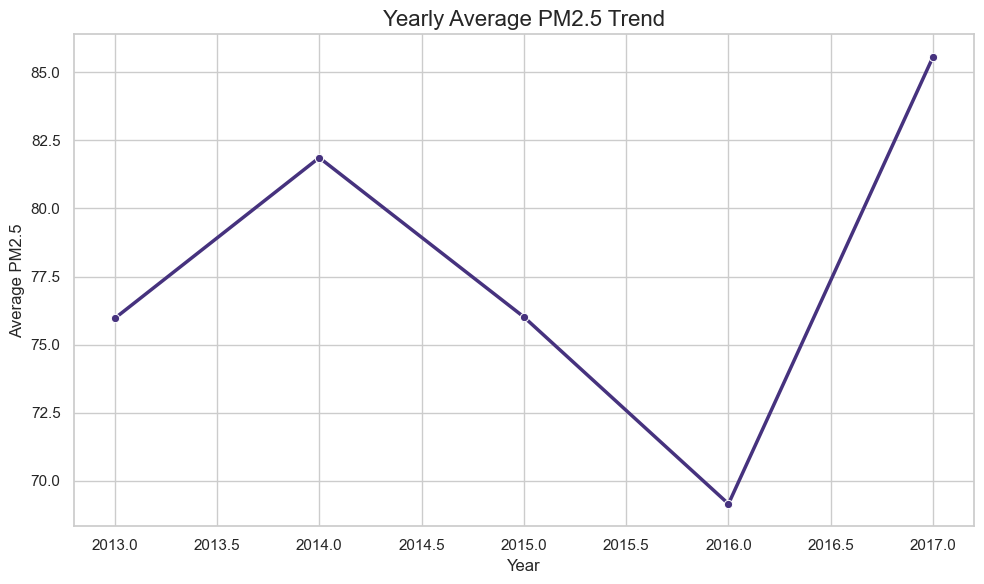

In [39]:
# Yearly PM2.5 Trend

yearly_pm25 = df_clean.groupby("year")["PM2.5"].mean()

plt.figure(figsize=(10, 6))
sns.lineplot(x=yearly_pm25.index, y=yearly_pm25.values, marker="o", linewidth=2.5)
plt.title("Yearly Average PM2.5 Trend")
plt.xlabel("Year")
plt.ylabel("Average PM2.5")
plt.tight_layout()
plt.show()

In [40]:
# Important EDA Tables

station_summary = df_clean.groupby("station")[pollutants].mean().round(2)
station_summary

,PM2.5,PM10,SO2,NO2,CO,O3
station,,,,,,
Dingling,66.85,84.11,11.80,27.30,925.11,70.53
Dongsi,86.14,110.35,18.51,53.95,1331.91,57.70
Huairou,69.50,92.42,12.45,32.08,1019.67,60.87
Tiantan,82.03,106.54,14.51,53.26,1305.33,56.15


In [41]:
monthly_summary = df_clean.groupby("month")["PM2.5"].mean().round(2)
monthly_summary

month
1     87.65
2     86.76
3     91.94
4     70.61
5     60.68
6     65.14
7     70.69
8     51.52
9     58.47
10    87.99
11    85.90
12    96.37
Name: PM2.5, dtype: float64

In [42]:
correlation_with_pm25 = correlation_matrix["PM2.5"].sort_values(ascending=False)
correlation_with_pm25

PM2.5    1.000000
PM10     0.878784
CO       0.786350
NO2      0.664288
SO2      0.465761
DEWP     0.125182
PRES     0.021862
RAIN    -0.014076
TEMP    -0.112893
O3      -0.124711
WSPM    -0.263278
Name: PM2.5, dtype: float64

In [43]:
# 8. Model Building

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

In [44]:
# Prepare model dataset

model_df = df_clean.copy()

station_encoder = LabelEncoder()
wd_encoder = LabelEncoder()
season_encoder = LabelEncoder()

model_df["station_encoded"] = station_encoder.fit_transform(model_df["station"])
model_df["wd_encoded"] = wd_encoder.fit_transform(model_df["wd"])
model_df["season_encoded"] = season_encoder.fit_transform(model_df["season"])

In [45]:
# Define features and target variable

features = [
    "PM10", "SO2", "NO2", "CO", "O3",
    "TEMP", "PRES", "DEWP", "RAIN", "WSPM",
    "year", "month", "day", "hour", "day_of_week",
    "station_encoded", "wd_encoded", "season_encoded"
]

target = "PM2.5"

X = model_df[features]
y = model_df[target]

In [46]:
# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (112204, 18)
Testing set shape: (28052, 18)


In [47]:
# Baseline Model: Linear Regression

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_pred)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
linear_r2 = r2_score(y_test, linear_pred)

print("Linear Regression Performance")
print("MAE:", round(linear_mae, 2))
print("RMSE:", round(linear_rmse, 2))
print("R2 Score:", round(linear_r2, 4))

Linear Regression Performance
MAE: 19.6
RMSE: 30.64
R2 Score: 0.8478


In [48]:
# Main Model: Random Forest Regressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Regressor Performance")
print("MAE:", round(rf_mae, 2))
print("RMSE:", round(rf_rmse, 2))
print("R2 Score:", round(rf_r2, 4))

Random Forest Regressor Performance
MAE: 10.15
RMSE: 17.44
R2 Score: 0.9507


In [49]:
# Main Model: Random Forest Regressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Regressor Performance")
print("MAE:", round(rf_mae, 2))
print("RMSE:", round(rf_rmse, 2))
print("R2 Score:", round(rf_r2, 4))

Random Forest Regressor Performance
MAE: 10.15
RMSE: 17.44
R2 Score: 0.9507


In [50]:
# Model Performance Comparison

model_results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest Regressor"],
    "MAE": [linear_mae, rf_mae],
    "RMSE": [linear_rmse, rf_rmse],
    "R2 Score": [linear_r2, rf_r2]
})

model_results.round(4)

,Model,MAE,RMSE,R2 Score
0,Linear Regression,19.5980,30.6398,0.8478
1,Random Forest Regressor,10.1484,17.4424,0.9507


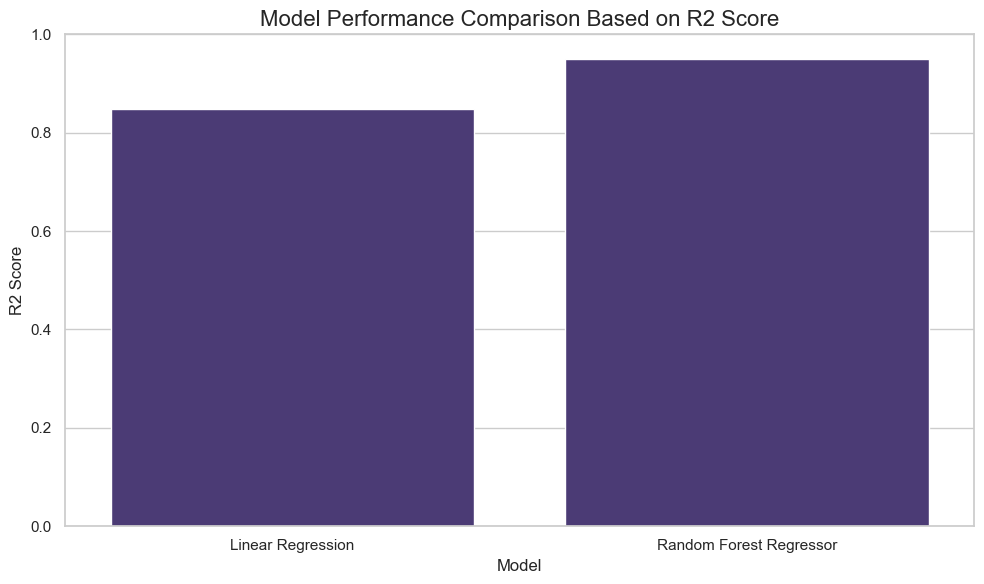

In [51]:
# Visualise Model Performance Comparison

plt.figure(figsize=(10, 6))
sns.barplot(data=model_results, x="Model", y="R2 Score")
plt.title("Model Performance Comparison Based on R2 Score")
plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

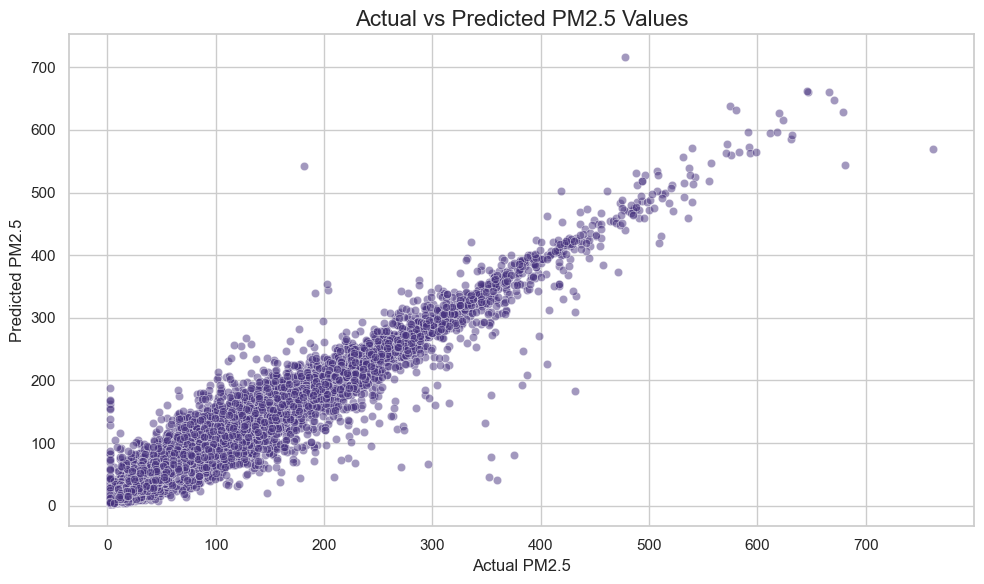

In [52]:
# Actual vs Predicted PM2.5

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=rf_pred, alpha=0.5)
plt.title("Actual vs Predicted PM2.5 Values")
plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")
plt.tight_layout()
plt.show()

In [53]:
# Feature Importance

feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
0,PM10,0.801405
3,CO,0.100081
7,DEWP,0.015687
1,SO2,0.012392
2,NO2,0.008808
5,TEMP,0.008229
6,PRES,0.007138
4,O3,0.006641
12,day,0.006513
11,month,0.006101


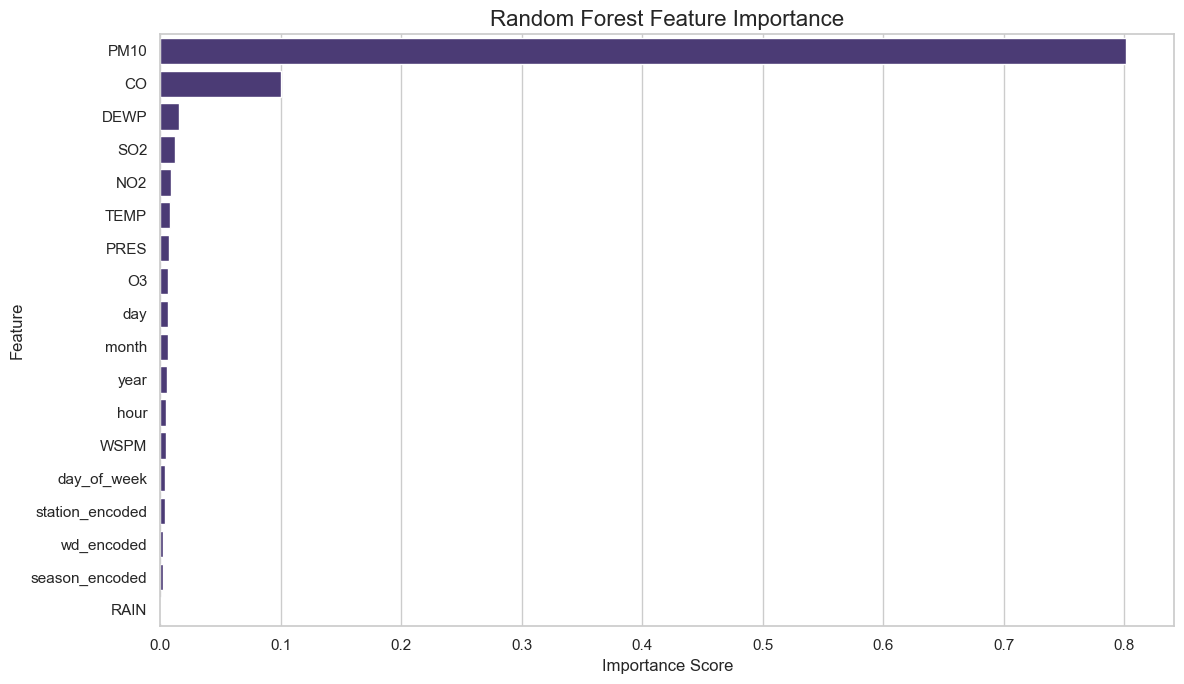

In [54]:
# Feature Importance Visualisation

plt.figure(figsize=(12, 7))
sns.barplot(data=feature_importance, x="Importance", y="Feature")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [55]:
# 9. Save Cleaned Dataset and Model

from pathlib import Path

processed_path = Path("../data/processed")
models_path = Path("../models")

processed_path.mkdir(parents=True, exist_ok=True)
models_path.mkdir(parents=True, exist_ok=True)

In [56]:
# Save cleaned dataset

df_clean.to_csv(processed_path / "cleaned_air_quality.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [57]:
# Save trained model and encoders

joblib.dump(rf_model, models_path / "pm25_random_forest_model.pkl")
joblib.dump(station_encoder, models_path / "station_encoder.pkl")
joblib.dump(wd_encoder, models_path / "wd_encoder.pkl")
joblib.dump(season_encoder, models_path / "season_encoder.pkl")

print("Model and encoders saved successfully.")

Model and encoders saved successfully.


In [58]:
# Save model performance results

model_results.to_csv(processed_path / "model_performance_results.csv", index=False)
feature_importance.to_csv(processed_path / "feature_importance.csv", index=False)

print("Model results and feature importance saved successfully.")

Model results and feature importance saved successfully.


In [59]:
# Final check

print("Final cleaned dataset shape:", df_clean.shape)
print("Saved files:")
print("- cleaned_air_quality.csv")
print("- pm25_random_forest_model.pkl")
print("- station_encoder.pkl")
print("- wd_encoder.pkl")
print("- season_encoder.pkl")
print("- model_performance_results.csv")
print("- feature_importance.csv")

Final cleaned dataset shape: (140256, 22)
Saved files:
- cleaned_air_quality.csv
- pm25_random_forest_model.pkl
- station_encoder.pkl
- wd_encoder.pkl
- season_encoder.pkl
- model_performance_results.csv
- feature_importance.csv
